# 4. Positive vs Negative 스코어 분포 분석

본 노트북은 Negative 스코어 분포가 Positive 스코어 영역을 침범하는지 확인합니다.
**Hard Negative가 심한 경우, Negative 스코어가 Positive 스코어 영역과 겹치거나 침범합니다.**


## 4.1. 분석 목표

### 핵심 질문
- **Negative 스코어 분포가 Positive 스코어 영역을 침범하는가?**
- **Hard Negative의 심각도는 어느 정도인가?**
- **두 분포의 겹침 정도는?**
- **통계적으로 유의미한 차이가 있는가?**


In [1]:
# 가상환경(.venv) 경로 자동 추가import sysfrom pathlib import Path# 프로젝트 루트 찾기project_root = Path().resolve().parent.parentvenv_path = project_root / ".venv"if venv_path.exists():    # Python 버전에 맞는 site-packages 경로 찾기    python_version = f"{sys.version_info.major}.{sys.version_info.minor}"    venv_site_packages = venv_path / "lib" / f"python{python_version}" / "site-packages"        # site-packages가 없으면 다른 가능한 경로 시도    if not venv_site_packages.exists():        lib_dir = venv_path / "lib"        if lib_dir.exists():            for py_dir in lib_dir.iterdir():                if py_dir.is_dir() and py_dir.name.startswith("python"):                    site_packages = py_dir / "site-packages"                    if site_packages.exists():                        venv_site_packages = site_packages                        break        if venv_site_packages.exists():        venv_path_str = str(venv_site_packages)        if venv_path_str not in sys.path:            sys.path.insert(0, venv_path_str)        print(f"✅ 가상환경(.venv) 경로 추가됨: {venv_site_packages}")    else:        print(f"⚠️ 가상환경(.venv)이 존재하지만 site-packages를 찾을 수 없습니다")else:    print(f"ℹ️ 가상환경(.venv)이 없습니다. 시스템 Python을 사용합니다")
# 노트북 독립 실행을 위한 환경 설정import sysfrom pathlib import Path# 프로젝트 루트를 sys.path에 추가project_root = Path().resolve().parent.parentif str(project_root) not in sys.path:    sys.path.insert(0, str(project_root))# 공통 유틸리티 importtry:    from notebooks.utils import setup_notebook_environment, load_dataset_safely, load_json_safely        # 환경 설정    paths = setup_notebook_environment()    print(f"✅ 프로젝트 루트: {paths['project_root']}")    print(f"✅ 데이터 디렉토리: {paths['data_dir']}")except ImportError as e:    print(f"⚠️ 유틸리티 import 실패: {e}")    paths = {        'project_root': project_root,        'data_dir': project_root / 'data',        'notebook_dir': project_root / 'notebooks'    }
# OpenMP 충돌 방지 설정 (Windows 환경)
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'

# 필요한 라이브러리 import
import sys
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from datasets import load_from_disk
from typing import List, Dict, Tuple
from tqdm import tqdm
import re
from scipy import stats
from scipy.stats import ks_2samp, mannwhitneyu

# 프로젝트 루트 경로 설정
project_root = Path().resolve().parent.parent
sys.path.append(str(project_root))

# 시각화 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 8)
sns.set_style("whitegrid")

print(f"프로젝트 루트: {project_root}")


d:\Repos\pro-nlp-mrc-nlp-01\.conda\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


프로젝트 루트: D:\Repos\pro-nlp-mrc-nlp-01


In [2]:
# 데이터 경로 설정
data_root = project_root / "data"
train_dataset_path = data_root / "train_dataset"
wikipedia_documents_path = data_root / "wikipedia_documents.json"

# 데이터 로드
print("데이터셋 로드 중...")
train_datasets = load_from_disk(str(train_dataset_path))

with open(wikipedia_documents_path, 'r', encoding='utf-8') as f:
    wiki_documents = json.load(f)

print(f"Train dataset: {len(train_datasets['train'])} samples")
print(f"Validation dataset: {len(train_datasets['validation'])} samples")
print(f"Wikipedia documents: {len(wiki_documents)} documents")


데이터셋 로드 중...
Train dataset: 3952 samples
Validation dataset: 240 samples
Wikipedia documents: 60613 documents


## 4.2. BM25 Retrieval 시스템 구축


In [3]:
# BM25 직접 구현
from collections import Counter
import math

def tokenize(text: str) -> List[str]:
    """간단한 토크나이저 - 공백 기준 분리"""
    return text.lower().split()

class BM25Retriever:
    """BM25 알고리즘을 사용한 Retrieval 시스템"""
    
    def __init__(self, contexts: List[str], k1: float = 1.5, b: float = 0.75):
        """
        Args:
            contexts: 검색 대상 문서 리스트
            k1: term frequency saturation parameter (기본값: 1.5)
            b: length normalization parameter (기본값: 0.75)
        """
        self.contexts = contexts
        self.k1 = k1
        self.b = b
        
        # 문서 토큰화 및 통계 계산
        print("BM25 인덱스 구축 중...")
        self.tokenized_docs = [tokenize(doc) for doc in tqdm(contexts, desc="Tokenizing documents")]
        
        # 문서별 단어 빈도 계산
        self.doc_freqs = []
        self.doc_lengths = []
        
        for doc_tokens in self.tokenized_docs:
            doc_freq = Counter(doc_tokens)
            self.doc_freqs.append(doc_freq)
            self.doc_lengths.append(len(doc_tokens))
        
        # 전체 문서 평균 길이
        self.avg_doc_length = sum(self.doc_lengths) / len(self.doc_lengths) if self.doc_lengths else 0
        
        # 전체 문서에서의 단어 빈도 (IDF 계산용)
        self.doc_freq = Counter()
        for doc_freq in self.doc_freqs:
            self.doc_freq.update(doc_freq.keys())
        
        self.num_docs = len(self.contexts)
        print(f"BM25 인덱스 구축 완료: {self.num_docs}개 문서")
    
    def get_idf(self, term: str) -> float:
        """Inverse Document Frequency 계산"""
        if term not in self.doc_freq:
            return 0.0
        return math.log((self.num_docs - self.doc_freq[term] + 0.5) / (self.doc_freq[term] + 0.5))
    
    def get_score(self, query_tokens: List[str], doc_idx: int) -> float:
        """BM25 점수 계산"""
        score = 0.0
        doc_freq = self.doc_freqs[doc_idx]
        doc_length = self.doc_lengths[doc_idx]
        
        for term in query_tokens:
            if term in doc_freq:
                # Term frequency
                tf = doc_freq[term]
                
                # BM25 공식
                idf = self.get_idf(term)
                numerator = idf * tf * (self.k1 + 1)
                denominator = tf + self.k1 * (1 - self.b + self.b * (doc_length / self.avg_doc_length))
                score += numerator / denominator
        
        return score
    
    def get_relevant_doc(self, query: str, k: int = 10) -> Tuple[List[float], List[int]]:
        """질문에 대해 상위 k개 문서 검색"""
        query_tokens = tokenize(query)
        
        # 모든 문서에 대해 점수 계산
        scores = []
        for doc_idx in range(self.num_docs):
            score = self.get_score(query_tokens, doc_idx)
            scores.append((score, doc_idx))
        
        # 점수 기준 내림차순 정렬
        scores.sort(reverse=True, key=lambda x: x[0])
        
        # 상위 k개 반환
        top_k = scores[:k]
        doc_scores = [score for score, _ in top_k]
        doc_indices = [idx for _, idx in top_k]
        
        return doc_scores, doc_indices

# BM25 Retrieval 시스템 초기화
print("BM25 Retrieval 시스템 초기화 중...")
context_texts = [v["text"] for v in wiki_documents.values()]
contexts = list(dict.fromkeys(context_texts))  # 중복 제거

retriever = BM25Retriever(contexts, k1=1.5, b=0.75)
print("BM25 Retrieval 시스템 준비 완료")


BM25 Retrieval 시스템 초기화 중...
BM25 인덱스 구축 중...


Tokenizing documents: 100%|██████████| 56737/56737 [00:01<00:00, 32380.88it/s]


BM25 인덱스 구축 완료: 56737개 문서
BM25 Retrieval 시스템 준비 완료


## 4.3. Positive vs Negative 스코어 수집


In [4]:
def check_answer_in_context(answer_text: str, context: str) -> bool:
    """Context에 정답이 포함되어 있는지 확인"""
    if not answer_text or not context:
        return False
    # 대소문자 무시하고 공백 정규화
    answer_normalized = re.sub(r'\s+', ' ', answer_text.strip().lower())
    context_normalized = re.sub(r'\s+', ' ', context.strip().lower())
    return answer_normalized in context_normalized

def collect_positive_negative_scores(
    dataset,
    retriever: BM25Retriever,
    top_k: int = 20
) -> Dict:
    """
    Positive와 Negative 스코어를 수집합니다.
    
    Returns:
        - positive_scores: 정답이 포함된 문서의 BM25 점수 리스트
        - negative_scores: 정답이 포함되지 않은 문서의 BM25 점수 리스트
    """
    positive_scores = []
    negative_scores = []
    
    positive_details = []  # 디버깅 및 분석용
    negative_details = []
    
    print(f"Positive/Negative 스코어 수집 중 (Top-{top_k} 분석)...")
    
    for example in tqdm(dataset, desc="Collecting scores"):
        question = example['question']
        answers = example.get('answers', {})
        answer_texts = answers.get('text', [])
        original_context = example.get('context', '')
        
        if answer_texts and len(answer_texts) > 0 and answer_texts[0].strip():
            answer_text = answer_texts[0].strip()
            
            try:
                # Top-K retrieval
                doc_scores, doc_indices = retriever.get_relevant_doc(question, k=top_k)
                retrieved_contexts = [retriever.contexts[idx] for idx in doc_indices]
                
                # 각 문서에 대해 Positive/Negative 분류
                for rank, (ctx, score) in enumerate(zip(retrieved_contexts, doc_scores), 1):
                    if check_answer_in_context(answer_text, ctx):
                        # Positive: 정답이 포함된 문서
                        positive_scores.append(float(score))
                        positive_details.append({
                            'question': question,
                            'answer': answer_text,
                            'context': ctx[:100] + '...' if len(ctx) > 100 else ctx,
                            'score': float(score),
                            'rank': rank
                        })
                    else:
                        # Negative: 정답이 포함되지 않은 문서
                        negative_scores.append(float(score))
                        negative_details.append({
                            'question': question,
                            'answer': answer_text,
                            'context': ctx[:100] + '...' if len(ctx) > 100 else ctx,
                            'score': float(score),
                            'rank': rank
                        })
            except Exception as e:
                continue
    
    return {
        'positive_scores': positive_scores,
        'negative_scores': negative_scores,
        'positive_details': positive_details,
        'negative_details': negative_details
    }

# Validation set에서 스코어 수집
print("\n=== Validation Set에서 스코어 수집 ===")
score_data = collect_positive_negative_scores(
    train_datasets['validation'],
    retriever,
    top_k=20
)

print(f"\n수집된 스코어:")
print(f"  - Positive 스코어: {len(score_data['positive_scores'])}개")
print(f"  - Negative 스코어: {len(score_data['negative_scores'])}개")



=== Validation Set에서 스코어 수집 ===
Positive/Negative 스코어 수집 중 (Top-20 분석)...



수집된 스코어:
  - Positive 스코어: 321개
  - Negative 스코어: 4479개


## 4.4. 스코어 분포 통계 분석


In [5]:
# 통계 분석
positive_scores = np.array(score_data['positive_scores'])
negative_scores = np.array(score_data['negative_scores'])

print("=" * 80)
print("Positive vs Negative 스코어 통계 분석")
print("=" * 80)

print("\n[Positive 스코어 통계]")
if len(positive_scores) > 0:
    print(f"  - 개수: {len(positive_scores)}")
    print(f"  - 평균: {np.mean(positive_scores):.4f}")
    print(f"  - 중앙값: {np.median(positive_scores):.4f}")
    print(f"  - 표준편차: {np.std(positive_scores):.4f}")
    print(f"  - 최소값: {np.min(positive_scores):.4f}")
    print(f"  - 최대값: {np.max(positive_scores):.4f}")
    print(f"  - 25% 분위수: {np.percentile(positive_scores, 25):.4f}")
    print(f"  - 75% 분위수: {np.percentile(positive_scores, 75):.4f}")
else:
    print("  - Positive 스코어가 없습니다.")

print("\n[Negative 스코어 통계]")
if len(negative_scores) > 0:
    print(f"  - 개수: {len(negative_scores)}")
    print(f"  - 평균: {np.mean(negative_scores):.4f}")
    print(f"  - 중앙값: {np.median(negative_scores):.4f}")
    print(f"  - 표준편차: {np.std(negative_scores):.4f}")
    print(f"  - 최소값: {np.min(negative_scores):.4f}")
    print(f"  - 최대값: {np.max(negative_scores):.4f}")
    print(f"  - 25% 분위수: {np.percentile(negative_scores, 25):.4f}")
    print(f"  - 75% 분위수: {np.percentile(negative_scores, 75):.4f}")
else:
    print("  - Negative 스코어가 없습니다.")

# 분포 겹침 분석
print("\n[분포 겹침 분석]")
if len(positive_scores) > 0 and len(negative_scores) > 0:
    # Negative가 Positive 영역을 침범하는지 확인
    pos_min = np.min(positive_scores)
    pos_max = np.max(positive_scores)
    pos_mean = np.mean(positive_scores)
    pos_median = np.median(positive_scores)
    
    neg_max = np.max(negative_scores)
    neg_mean = np.mean(negative_scores)
    neg_median = np.median(negative_scores)
    
    # Negative 스코어가 Positive 최소값보다 높은 비율
    neg_above_pos_min = np.sum(negative_scores >= pos_min) / len(negative_scores) * 100
    neg_above_pos_median = np.sum(negative_scores >= pos_median) / len(negative_scores) * 100
    neg_above_pos_mean = np.sum(negative_scores >= pos_mean) / len(negative_scores) * 100
    
    print(f"  - Negative 스코어 >= Positive 최소값 ({pos_min:.4f}): {neg_above_pos_min:.2f}%")
    print(f"  - Negative 스코어 >= Positive 중앙값 ({pos_median:.4f}): {neg_above_pos_median:.2f}%")
    print(f"  - Negative 스코어 >= Positive 평균 ({pos_mean:.4f}): {neg_above_pos_mean:.2f}%")
    print(f"  - Negative 최대값 ({neg_max:.4f}) vs Positive 최대값 ({pos_max:.4f})")
    print(f"  - Negative 최대값이 Positive 최대값의 {neg_max/pos_max*100:.2f}%")
    
    # Negative가 Positive 영역을 침범하는 정도
    if neg_max >= pos_min:
        overlap_ratio = (min(neg_max, pos_max) - max(neg_min := np.min(negative_scores), pos_min)) / (pos_max - pos_min) * 100
        print(f"  - 겹침 구간: [{max(neg_min, pos_min):.4f}, {min(neg_max, pos_max):.4f}]")
        print(f"  - Positive 범위 대비 겹침 비율: {overlap_ratio:.2f}%")
    
    # 통계적 검정
    print("\n[통계적 검정]")
    # Kolmogorov-Smirnov test (분포 차이 검정)
    ks_statistic, ks_pvalue = ks_2samp(positive_scores, negative_scores)
    print(f"  - Kolmogorov-Smirnov test:")
    print(f"    통계량: {ks_statistic:.4f}, p-value: {ks_pvalue:.6f}")
    if ks_pvalue < 0.05:
        print(f"    → 두 분포는 통계적으로 유의미하게 다릅니다 (p < 0.05)")
    else:
        print(f"    → 두 분포는 통계적으로 유의미한 차이가 없습니다 (p >= 0.05)")
    
    # Mann-Whitney U test (중앙값 차이 검정)
    u_statistic, u_pvalue = mannwhitneyu(positive_scores, negative_scores, alternative='two-sided')
    print(f"  - Mann-Whitney U test:")
    print(f"    통계량: {u_statistic:.4f}, p-value: {u_pvalue:.6f}")
    if u_pvalue < 0.05:
        print(f"    → 두 분포의 중앙값은 통계적으로 유의미하게 다릅니다 (p < 0.05)")
    else:
        print(f"    → 두 분포의 중앙값은 통계적으로 유의미한 차이가 없습니다 (p >= 0.05)")

print("\n" + "=" * 80)


Positive vs Negative 스코어 통계 분석

[Positive 스코어 통계]
  - 개수: 321
  - 평균: 19.1381
  - 중앙값: 16.8565
  - 표준편차: 9.5324
  - 최소값: 0.0000
  - 최대값: 53.3684
  - 25% 분위수: 11.5615
  - 75% 분위수: 24.8124

[Negative 스코어 통계]
  - 개수: 4479
  - 평균: 11.5340
  - 중앙값: 11.0851
  - 표준편차: 3.3412
  - 최소값: 0.0000
  - 최대값: 35.9365
  - 25% 분위수: 9.6646
  - 75% 분위수: 12.9126

[분포 겹침 분석]
  - Negative 스코어 >= Positive 최소값 (0.0000): 100.00%
  - Negative 스코어 >= Positive 중앙값 (16.8565): 5.89%
  - Negative 스코어 >= Positive 평균 (19.1381): 2.84%
  - Negative 최대값 (35.9365) vs Positive 최대값 (53.3684)
  - Negative 최대값이 Positive 최대값의 67.34%
  - 겹침 구간: [0.0000, 35.9365]
  - Positive 범위 대비 겹침 비율: 67.34%

[통계적 검정]
  - Kolmogorov-Smirnov test:
    통계량: 0.4928, p-value: 0.000000
    → 두 분포는 통계적으로 유의미하게 다릅니다 (p < 0.05)
  - Mann-Whitney U test:
    통계량: 1097491.0000, p-value: 0.000000
    → 두 분포의 중앙값은 통계적으로 유의미하게 다릅니다 (p < 0.05)



## 4.5. 스코어 분포 시각화


C:\Users\pilla\AppData\Local\Temp\ipykernel_19928\3779156873.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(data_to_plot, labels=labels, patch_artist=True,


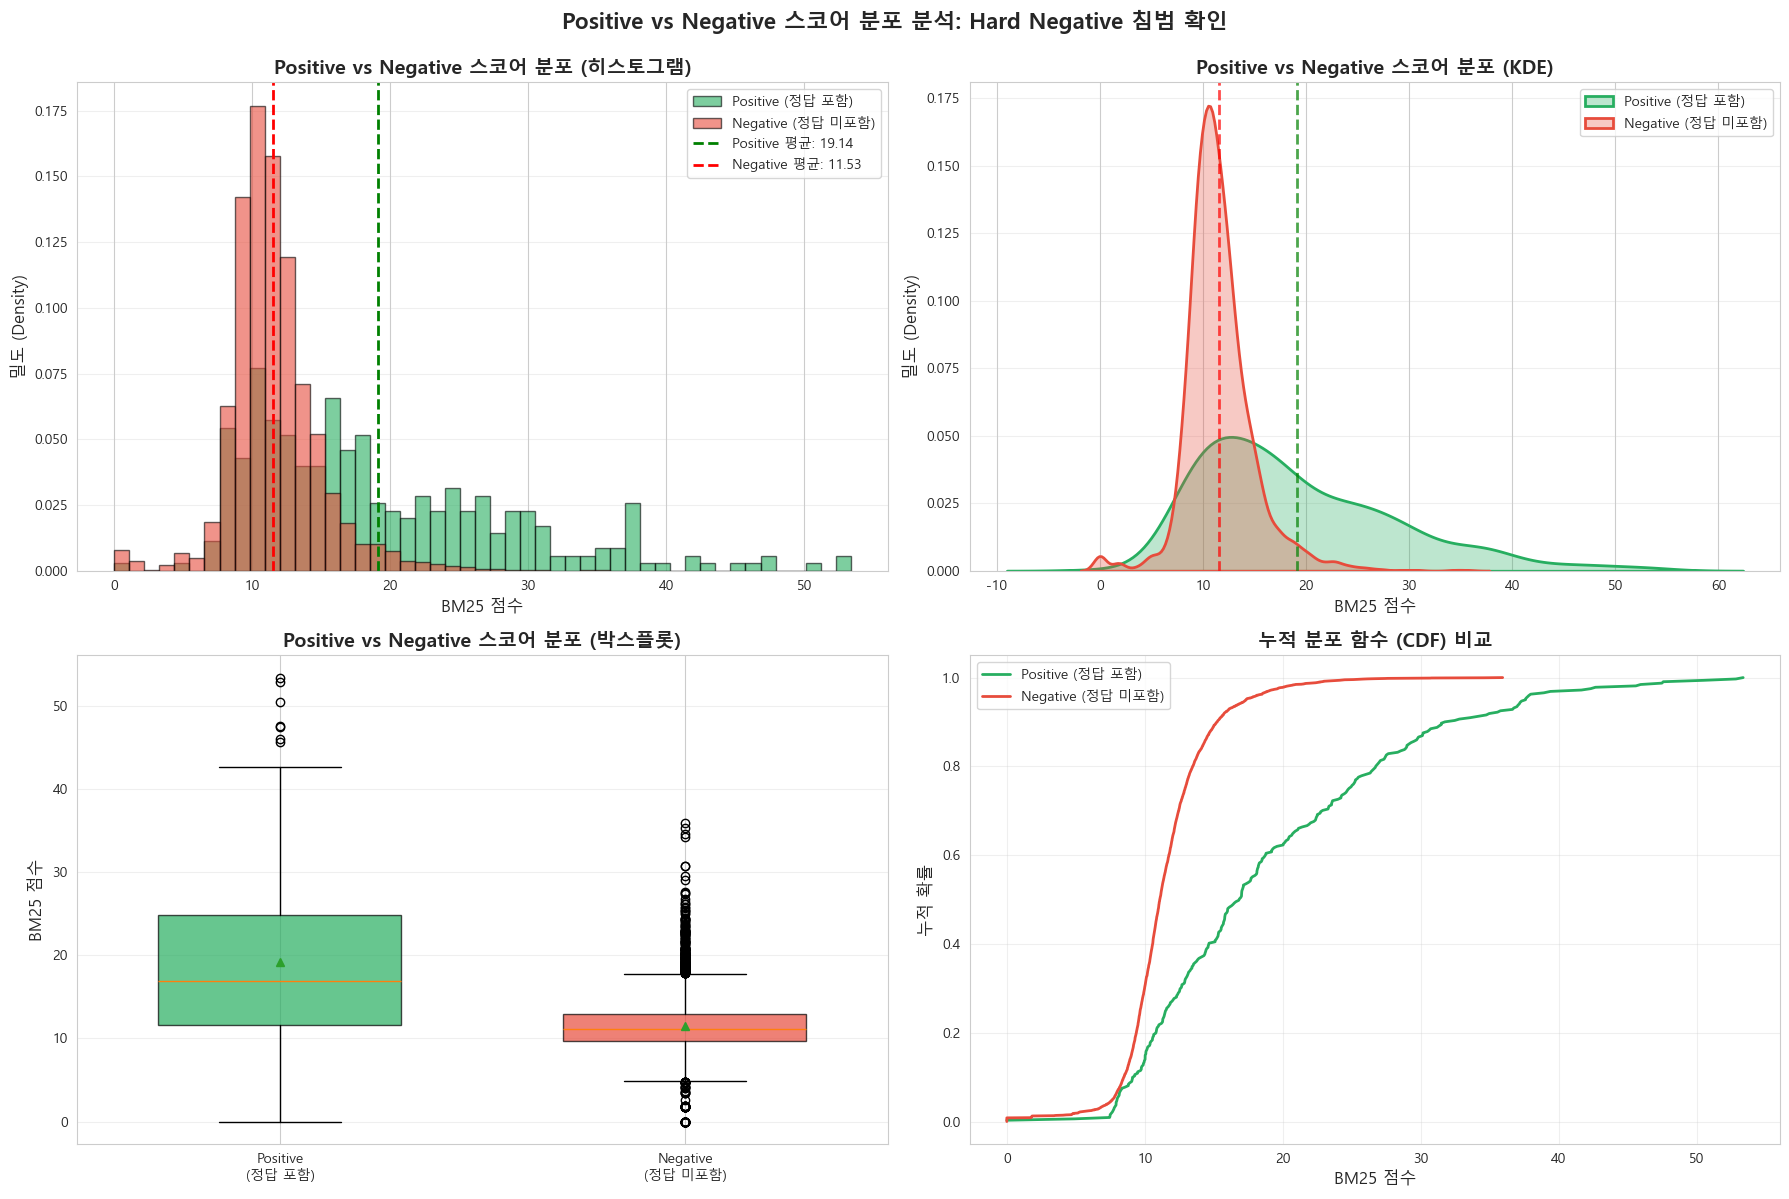

In [6]:
# 한글 폰트 설정
import matplotlib
import platform

def set_korean_font():
    system = platform.system()
    if system == 'Windows':
        font_name = 'Malgun Gothic'
    elif system == 'Darwin':  # Mac
        font_name = 'AppleGothic'
    else:  # Linux
        font_name = 'NanumGothic'
    matplotlib.rc('font', family=font_name)
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. 히스토그램 비교
ax1 = axes[0, 0]
if len(positive_scores) > 0 and len(negative_scores) > 0:
    # 공통 bins 설정
    all_scores = np.concatenate([positive_scores, negative_scores])
    bins = np.linspace(min(all_scores), max(all_scores), 50)
    
    ax1.hist(positive_scores, bins=bins, alpha=0.6, label='Positive (정답 포함)', 
             color='#27ae60', edgecolor='black', density=True)
    ax1.hist(negative_scores, bins=bins, alpha=0.6, label='Negative (정답 미포함)', 
             color='#e74c3c', edgecolor='black', density=True)
    
    # 평균선 표시
    ax1.axvline(np.mean(positive_scores), color='green', linestyle='--', 
                linewidth=2, label=f'Positive 평균: {np.mean(positive_scores):.2f}')
    ax1.axvline(np.mean(negative_scores), color='red', linestyle='--', 
                linewidth=2, label=f'Negative 평균: {np.mean(negative_scores):.2f}')
    
    ax1.set_xlabel('BM25 점수', fontsize=12)
    ax1.set_ylabel('밀도 (Density)', fontsize=12)
    ax1.set_title('Positive vs Negative 스코어 분포 (히스토그램)', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(axis='y', alpha=0.3)

# 2. KDE (Kernel Density Estimation) 비교
ax2 = axes[0, 1]
if len(positive_scores) > 0 and len(negative_scores) > 0:
    sns.kdeplot(positive_scores, ax=ax2, label='Positive (정답 포함)', 
                color='#27ae60', linewidth=2, fill=True, alpha=0.3)
    sns.kdeplot(negative_scores, ax=ax2, label='Negative (정답 미포함)', 
                color='#e74c3c', linewidth=2, fill=True, alpha=0.3)
    
    # 평균선 표시
    ax2.axvline(np.mean(positive_scores), color='green', linestyle='--', 
                linewidth=2, alpha=0.7)
    ax2.axvline(np.mean(negative_scores), color='red', linestyle='--', 
                linewidth=2, alpha=0.7)
    
    ax2.set_xlabel('BM25 점수', fontsize=12)
    ax2.set_ylabel('밀도 (Density)', fontsize=12)
    ax2.set_title('Positive vs Negative 스코어 분포 (KDE)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(axis='y', alpha=0.3)

# 3. 박스플롯 비교
ax3 = axes[1, 0]
if len(positive_scores) > 0 and len(negative_scores) > 0:
    data_to_plot = [positive_scores, negative_scores]
    labels = ['Positive\n(정답 포함)', 'Negative\n(정답 미포함)']
    
    bp = ax3.boxplot(data_to_plot, labels=labels, patch_artist=True, 
                     widths=0.6, showmeans=True)
    colors_box = ['#27ae60', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax3.set_ylabel('BM25 점수', fontsize=12)
    ax3.set_title('Positive vs Negative 스코어 분포 (박스플롯)', fontsize=14, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)

# 4. 누적 분포 함수 (CDF) 비교
ax4 = axes[1, 1]
if len(positive_scores) > 0 and len(negative_scores) > 0:
    # 정렬된 스코어
    pos_sorted = np.sort(positive_scores)
    neg_sorted = np.sort(negative_scores)
    
    # CDF 계산
    pos_cdf = np.arange(1, len(pos_sorted) + 1) / len(pos_sorted)
    neg_cdf = np.arange(1, len(neg_sorted) + 1) / len(neg_sorted)
    
    ax4.plot(pos_sorted, pos_cdf, label='Positive (정답 포함)', 
             color='#27ae60', linewidth=2)
    ax4.plot(neg_sorted, neg_cdf, label='Negative (정답 미포함)', 
             color='#e74c3c', linewidth=2)
    
    ax4.set_xlabel('BM25 점수', fontsize=12)
    ax4.set_ylabel('누적 확률', fontsize=12)
    ax4.set_title('누적 분포 함수 (CDF) 비교', fontsize=14, fontweight='bold')
    ax4.legend(fontsize=10)
    ax4.grid(alpha=0.3)

plt.suptitle('Positive vs Negative 스코어 분포 분석: Hard Negative 침범 확인', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## 4.6. 침범 정도 정량화


In [7]:
# 침범 정도 정량화
print("=" * 80)
print("Negative 스코어가 Positive 영역을 침범하는 정도 분석")
print("=" * 80)

if len(positive_scores) > 0 and len(negative_scores) > 0:
    pos_scores = positive_scores
    neg_scores = negative_scores
    
    # 1. Percentile 기반 침범 분석
    print("\n[Percentile 기반 침범 분석]")
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    for p in percentiles:
        pos_percentile = np.percentile(pos_scores, p)
        neg_above = np.sum(neg_scores >= pos_percentile) / len(neg_scores) * 100
        print(f"  - Negative 스코어 >= Positive {p}% 분위수 ({pos_percentile:.4f}): {neg_above:.2f}%")
    
    # 2. 구간별 침범 분석
    print("\n[구간별 침범 분석]")
    pos_min, pos_25, pos_50, pos_75, pos_max = np.percentile(pos_scores, [0, 25, 50, 75, 100])
    
    intervals = [
        ('최하위 25%', pos_min, pos_25),
        ('중위 25-50%', pos_25, pos_50),
        ('중위 50-75%', pos_50, pos_75),
        ('상위 25%', pos_75, pos_max)
    ]
    
    for interval_name, low, high in intervals:
        neg_in_interval = np.sum((neg_scores >= low) & (neg_scores <= high))
        neg_ratio = neg_in_interval / len(neg_scores) * 100
        pos_in_interval = np.sum((pos_scores >= low) & (pos_scores <= high))
        pos_ratio = pos_in_interval / len(pos_scores) * 100
        print(f"  - {interval_name} [{low:.2f}, {high:.2f}]:")
        print(f"    Negative: {neg_in_interval}개 ({neg_ratio:.2f}%)")
        print(f"    Positive: {pos_in_interval}개 ({pos_ratio:.2f}%)")
    
    # 3. Hard Negative 심각도 점수 계산
    print("\n[Hard Negative 심각도 점수]")
    
    # 방법 1: Negative가 Positive 평균 이상인 비율
    severity_score_1 = np.sum(neg_scores >= np.mean(pos_scores)) / len(neg_scores) * 100
    
    # 방법 2: Negative가 Positive 중앙값 이상인 비율
    severity_score_2 = np.sum(neg_scores >= np.median(pos_scores)) / len(neg_scores) * 100
    
    # 방법 3: Negative 최대값이 Positive 최대값의 비율
    severity_score_3 = np.max(neg_scores) / np.max(pos_scores) * 100
    
    # 방법 4: 분포 겹침 비율 (Jaccard similarity)
    all_scores = np.concatenate([pos_scores, neg_scores])
    score_range = (np.min(all_scores), np.max(all_scores))
    bins = np.linspace(score_range[0], score_range[1], 100)
    
    pos_hist, _ = np.histogram(pos_scores, bins=bins)
    neg_hist, _ = np.histogram(neg_scores, bins=bins)
    
    # 정규화
    pos_hist = pos_hist / (pos_hist.sum() + 1e-10)
    neg_hist = neg_hist / (neg_hist.sum() + 1e-10)
    
    # 겹침 비율 (교집합 / 합집합)
    intersection = np.minimum(pos_hist, neg_hist).sum()
    union = np.maximum(pos_hist, neg_hist).sum()
    overlap_ratio = intersection / (union + 1e-10) * 100
    
    print(f"  - 방법 1 (Negative >= Positive 평균 비율): {severity_score_1:.2f}%")
    print(f"  - 방법 2 (Negative >= Positive 중앙값 비율): {severity_score_2:.2f}%")
    print(f"  - 방법 3 (Negative 최대값 / Positive 최대값): {severity_score_3:.2f}%")
    print(f"  - 방법 4 (분포 겹침 비율): {overlap_ratio:.2f}%")
    
    # 종합 심각도 평가
    avg_severity = (severity_score_1 + severity_score_2 + severity_score_3 + overlap_ratio) / 4
    print(f"\n  → 종합 Hard Negative 심각도: {avg_severity:.2f}%")
    
    if avg_severity >= 50:
        print(f"    ⚠️  매우 심각: Negative 스코어가 Positive 영역을 크게 침범합니다.")
    elif avg_severity >= 30:
        print(f"    ⚠️  심각: Negative 스코어가 Positive 영역을 상당히 침범합니다.")
    elif avg_severity >= 15:
        print(f"    ⚠️  보통: Negative 스코어가 Positive 영역을 어느 정도 침범합니다.")
    else:
        print(f"    ✓ 양호: Negative 스코어가 Positive 영역을 크게 침범하지 않습니다.")

print("\n" + "=" * 80)


Negative 스코어가 Positive 영역을 침범하는 정도 분석

[Percentile 기반 침범 분석]
  - Negative 스코어 >= Positive 10% 분위수 (9.2614): 81.83%
  - Negative 스코어 >= Positive 25% 분위수 (11.5615): 42.51%
  - Negative 스코어 >= Positive 50% 분위수 (16.8565): 5.89%
  - Negative 스코어 >= Positive 75% 분위수 (24.8124): 0.49%
  - Negative 스코어 >= Positive 90% 분위수 (31.7516): 0.09%
  - Negative 스코어 >= Positive 95% 분위수 (37.5919): 0.00%
  - Negative 스코어 >= Positive 99% 분위수 (47.5539): 0.00%

[구간별 침범 분석]
  - 최하위 25% [0.00, 11.56]:
    Negative: 2575개 (57.49%)
    Positive: 81개 (25.23%)
  - 중위 25-50% [11.56, 16.86]:
    Negative: 1640개 (36.62%)
    Positive: 81개 (25.23%)
  - 중위 50-75% [16.86, 24.81]:
    Negative: 242개 (5.40%)
    Positive: 81개 (25.23%)
  - 상위 25% [24.81, 53.37]:
    Negative: 22개 (0.49%)
    Positive: 81개 (25.23%)

[Hard Negative 심각도 점수]
  - 방법 1 (Negative >= Positive 평균 비율): 2.84%
  - 방법 2 (Negative >= Positive 중앙값 비율): 5.89%
  - 방법 3 (Negative 최대값 / Positive 최대값): 67.34%
  - 방법 4 (분포 겹침 비율): 32.66%

  → 종합 Hard Negative 심각

## 4.7. 침범 정도 시각화


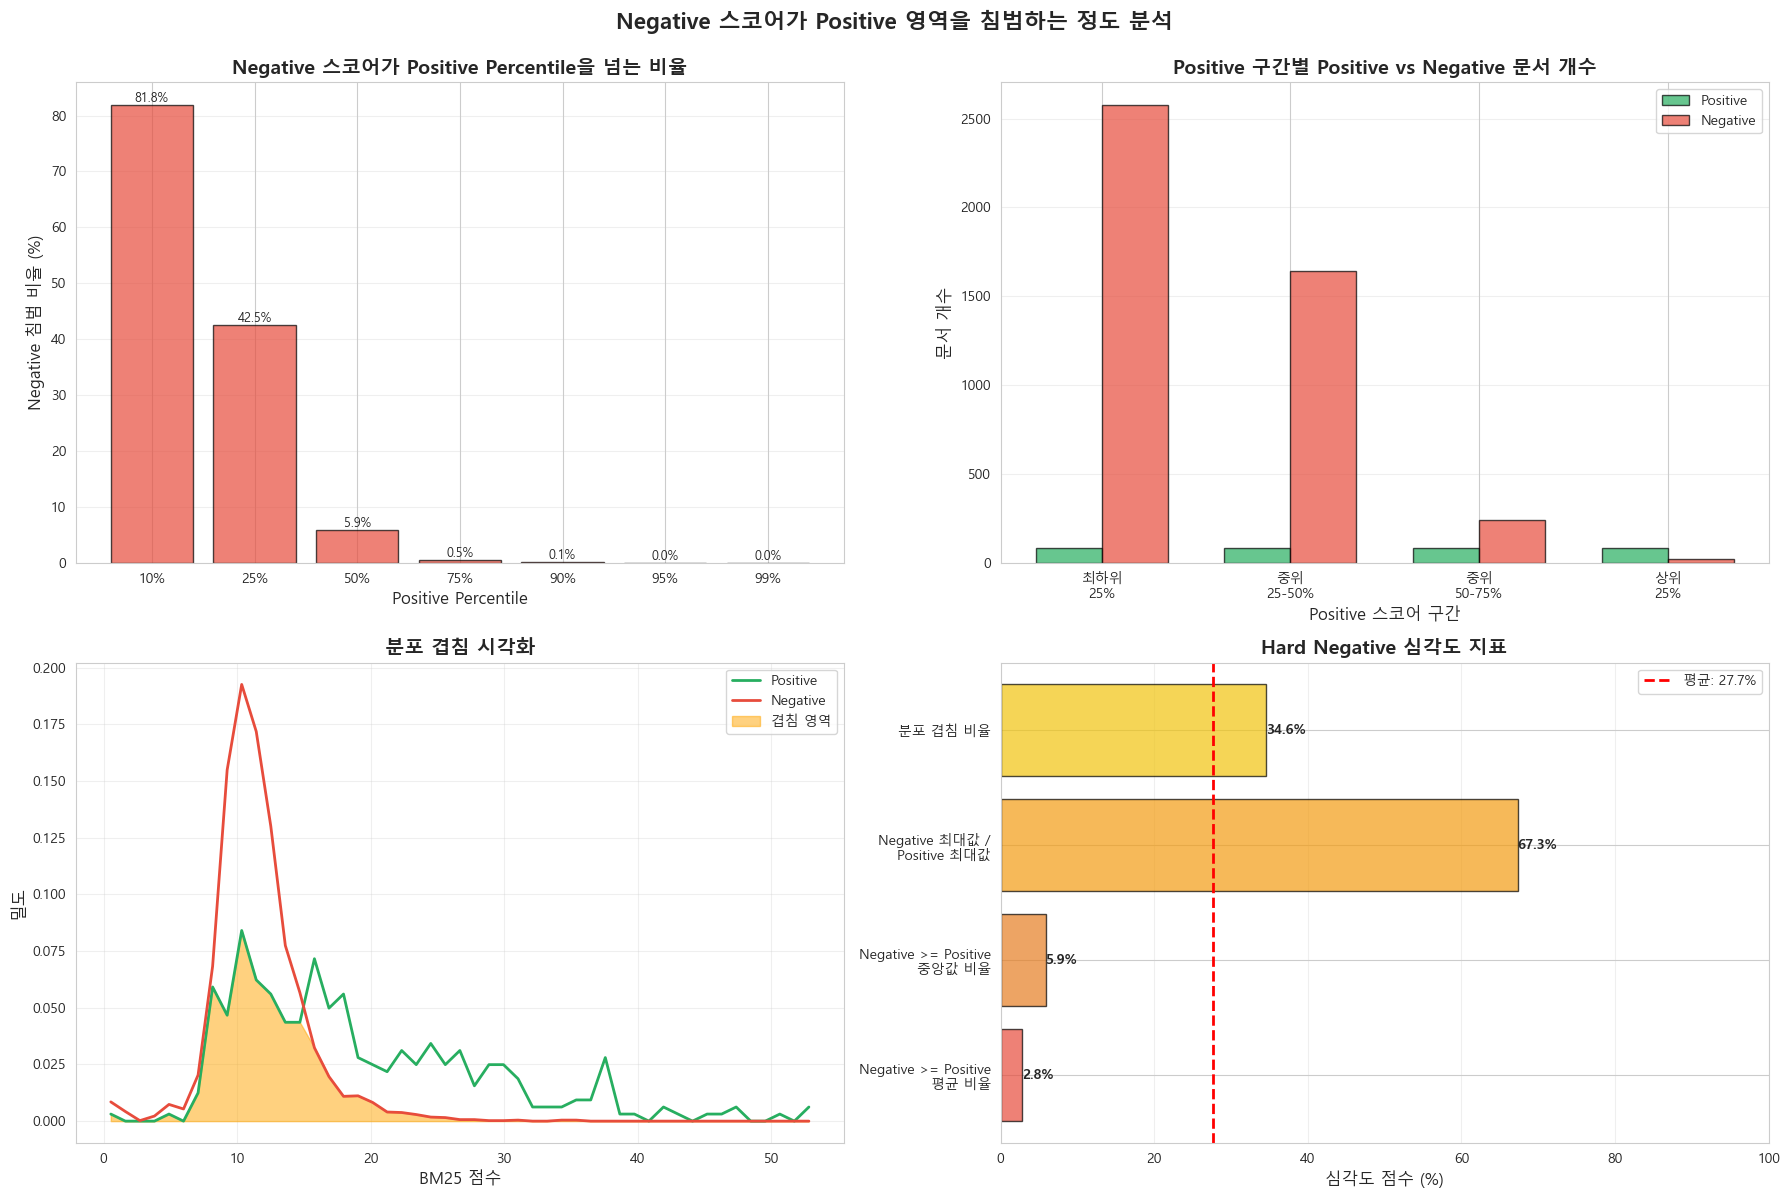

In [8]:
# 침범 정도 시각화
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

if len(positive_scores) > 0 and len(negative_scores) > 0:
    pos_scores = positive_scores
    neg_scores = negative_scores
    
    # 1. Percentile 침범 비율
    ax1 = axes[0, 0]
    percentiles = [10, 25, 50, 75, 90, 95, 99]
    pos_percentiles = [np.percentile(pos_scores, p) for p in percentiles]
    neg_above_ratios = [np.sum(neg_scores >= pp) / len(neg_scores) * 100 for pp in pos_percentiles]
    
    bars = ax1.bar(range(len(percentiles)), neg_above_ratios, 
                   color='#e74c3c', alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Positive Percentile', fontsize=12)
    ax1.set_ylabel('Negative 침범 비율 (%)', fontsize=12)
    ax1.set_title('Negative 스코어가 Positive Percentile을 넘는 비율', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(len(percentiles)))
    ax1.set_xticklabels([f'{p}%' for p in percentiles])
    ax1.grid(axis='y', alpha=0.3)
    
    for bar, ratio in zip(bars, neg_above_ratios):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{ratio:.1f}%',
                ha='center', va='bottom', fontsize=9)
    
    # 2. 구간별 분포 비교
    ax2 = axes[0, 1]
    pos_min, pos_25, pos_50, pos_75, pos_max = np.percentile(pos_scores, [0, 25, 50, 75, 100])
    
    intervals = ['최하위\n25%', '중위\n25-50%', '중위\n50-75%', '상위\n25%']
    interval_ranges = [(pos_min, pos_25), (pos_25, pos_50), (pos_50, pos_75), (pos_75, pos_max)]
    
    pos_counts = []
    neg_counts = []
    for low, high in interval_ranges:
        pos_counts.append(np.sum((pos_scores >= low) & (pos_scores <= high)))
        neg_counts.append(np.sum((neg_scores >= low) & (neg_scores <= high)))
    
    x = np.arange(len(intervals))
    width = 0.35
    
    bars1 = ax2.bar(x - width/2, pos_counts, width, label='Positive', 
                    color='#27ae60', alpha=0.7, edgecolor='black')
    bars2 = ax2.bar(x + width/2, neg_counts, width, label='Negative', 
                    color='#e74c3c', alpha=0.7, edgecolor='black')
    
    ax2.set_xlabel('Positive 스코어 구간', fontsize=12)
    ax2.set_ylabel('문서 개수', fontsize=12)
    ax2.set_title('Positive 구간별 Positive vs Negative 문서 개수', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(intervals)
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. 분포 겹침 히트맵
    ax3 = axes[1, 0]
    all_scores = np.concatenate([pos_scores, neg_scores])
    bins = np.linspace(np.min(all_scores), np.max(all_scores), 50)
    
    pos_hist, _ = np.histogram(pos_scores, bins=bins)
    neg_hist, _ = np.histogram(neg_scores, bins=bins)
    
    # 정규화
    pos_hist = pos_hist / (pos_hist.sum() + 1e-10)
    neg_hist = neg_hist / (neg_hist.sum() + 1e-10)
    
    # 겹침 계산
    overlap = np.minimum(pos_hist, neg_hist)
    
    x_centers = (bins[:-1] + bins[1:]) / 2
    ax3.plot(x_centers, pos_hist, label='Positive', color='#27ae60', linewidth=2)
    ax3.plot(x_centers, neg_hist, label='Negative', color='#e74c3c', linewidth=2)
    ax3.fill_between(x_centers, 0, overlap, alpha=0.5, color='orange', 
                     label='겹침 영역')
    
    ax3.set_xlabel('BM25 점수', fontsize=12)
    ax3.set_ylabel('밀도', fontsize=12)
    ax3.set_title('분포 겹침 시각화', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(alpha=0.3)
    
    # 4. 심각도 점수 요약
    ax4 = axes[1, 1]
    severity_scores = {
        'Negative >= Positive\n평균 비율': np.sum(neg_scores >= np.mean(pos_scores)) / len(neg_scores) * 100,
        'Negative >= Positive\n중앙값 비율': np.sum(neg_scores >= np.median(pos_scores)) / len(neg_scores) * 100,
        'Negative 최대값 /\nPositive 최대값': np.max(neg_scores) / np.max(pos_scores) * 100,
        '분포 겹침 비율': overlap.sum() / (np.maximum(pos_hist, neg_hist).sum() + 1e-10) * 100
    }
    
    categories = list(severity_scores.keys())
    values = list(severity_scores.values())
    colors_bar = ['#e74c3c', '#e67e22', '#f39c12', '#f1c40f']
    
    bars = ax4.barh(categories, values, color=colors_bar, alpha=0.7, edgecolor='black')
    ax4.set_xlabel('심각도 점수 (%)', fontsize=12)
    ax4.set_title('Hard Negative 심각도 지표', fontsize=14, fontweight='bold')
    ax4.set_xlim([0, max(100, max(values) * 1.1)])
    ax4.grid(axis='x', alpha=0.3)
    
    for i, (bar, val) in enumerate(zip(bars, values)):
        ax4.text(val, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%',
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    # 평균선 표시
    avg_severity = np.mean(values)
    ax4.axvline(avg_severity, color='red', linestyle='--', linewidth=2,
                label=f'평균: {avg_severity:.1f}%')
    ax4.legend()

plt.suptitle('Negative 스코어가 Positive 영역을 침범하는 정도 분석', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## 4.8. 결론 및 요약


In [9]:
# 최종 결론 및 리포트 생성
print("=" * 80)
print("분석 결론 및 요약")
print("=" * 80)

if len(positive_scores) > 0 and len(negative_scores) > 0:
    pos_scores = positive_scores
    neg_scores = negative_scores
    
    # 핵심 지표 계산
    neg_above_pos_mean = np.sum(neg_scores >= np.mean(pos_scores)) / len(neg_scores) * 100
    neg_above_pos_median = np.sum(neg_scores >= np.median(pos_scores)) / len(neg_scores) * 100
    neg_max_ratio = np.max(neg_scores) / np.max(pos_scores) * 100
    
    # 분포 겹침
    all_scores = np.concatenate([pos_scores, neg_scores])
    bins = np.linspace(np.min(all_scores), np.max(all_scores), 100)
    pos_hist, _ = np.histogram(pos_scores, bins=bins)
    neg_hist, _ = np.histogram(neg_scores, bins=bins)
    pos_hist = pos_hist / (pos_hist.sum() + 1e-10)
    neg_hist = neg_hist / (neg_hist.sum() + 1e-10)
    overlap_ratio = np.minimum(pos_hist, neg_hist).sum() / (np.maximum(pos_hist, neg_hist).sum() + 1e-10) * 100
    
    avg_severity = (neg_above_pos_mean + neg_above_pos_median + neg_max_ratio + overlap_ratio) / 4
    
    print("\n[핵심 발견]")
    print(f"1. Negative 스코어 >= Positive 평균: {neg_above_pos_mean:.2f}%")
    print(f"2. Negative 스코어 >= Positive 중앙값: {neg_above_pos_median:.2f}%")
    print(f"3. Negative 최대값 / Positive 최대값: {neg_max_ratio:.2f}%")
    print(f"4. 분포 겹침 비율: {overlap_ratio:.2f}%")
    print(f"\n→ 종합 Hard Negative 심각도: {avg_severity:.2f}%")
    
    print("\n[결론]")
    if avg_severity >= 50:
        conclusion = "매우 심각"
        recommendation = "Negative Sample Augmentation이 매우 필요합니다. Hard Negative가 Positive 영역을 크게 침범하여 모델이 혼동할 가능성이 높습니다."
    elif avg_severity >= 30:
        conclusion = "심각"
        recommendation = "Negative Sample Augmentation이 필요합니다. Hard Negative가 Positive 영역을 상당히 침범하고 있습니다."
    elif avg_severity >= 15:
        conclusion = "보통"
        recommendation = "Negative Sample Augmentation을 고려해볼 수 있습니다. Hard Negative가 Positive 영역을 어느 정도 침범하고 있습니다."
    else:
        conclusion = "양호"
        recommendation = "현재 상태는 양호하지만, 지속적인 모니터링이 필요합니다."
    
    print(f"  - Hard Negative 심각도: {conclusion}")
    print(f"  - 권장사항: {recommendation}")
    
    # 리포트 저장
    report = {
        'positive_stats': {
            'count': len(pos_scores),
            'mean': float(np.mean(pos_scores)),
            'median': float(np.median(pos_scores)),
            'std': float(np.std(pos_scores)),
            'min': float(np.min(pos_scores)),
            'max': float(np.max(pos_scores))
        },
        'negative_stats': {
            'count': len(neg_scores),
            'mean': float(np.mean(neg_scores)),
            'median': float(np.median(neg_scores)),
            'std': float(np.std(neg_scores)),
            'min': float(np.min(neg_scores)),
            'max': float(np.max(neg_scores))
        },
        'invasion_metrics': {
            'neg_above_pos_mean_ratio': float(neg_above_pos_mean),
            'neg_above_pos_median_ratio': float(neg_above_pos_median),
            'neg_max_ratio': float(neg_max_ratio),
            'overlap_ratio': float(overlap_ratio),
            'overall_severity': float(avg_severity)
        },
        'statistical_tests': {
            'ks_statistic': float(ks_statistic),
            'ks_pvalue': float(ks_pvalue),
            'mannwhitney_u_statistic': float(u_statistic),
            'mannwhitney_u_pvalue': float(u_pvalue)
        },
        'conclusion': conclusion,
        'recommendation': recommendation
    }
    
    report_path = project_root / "notebooks" / "negative_passage" / "score_distribution_report.json"
    with open(report_path, 'w', encoding='utf-8') as f:
        json.dump(report, f, ensure_ascii=False, indent=2)
    
    print(f"\n리포트가 저장되었습니다: {report_path}")

print("\n" + "=" * 80)


분석 결론 및 요약

[핵심 발견]
1. Negative 스코어 >= Positive 평균: 2.84%
2. Negative 스코어 >= Positive 중앙값: 5.89%
3. Negative 최대값 / Positive 최대값: 67.34%
4. 분포 겹침 비율: 32.66%

→ 종합 Hard Negative 심각도: 27.18%

[결론]
  - Hard Negative 심각도: 보통
  - 권장사항: Negative Sample Augmentation을 고려해볼 수 있습니다. Hard Negative가 Positive 영역을 어느 정도 침범하고 있습니다.

리포트가 저장되었습니다: D:\Repos\pro-nlp-mrc-nlp-01\notebooks\negative_passage\score_distribution_report.json

